In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os
import sys

In [110]:
df_targets = pd.read_csv('../dataset/y_train_hCIvDMj.csv')
print(len(df_targets))

4400


<Axes: >

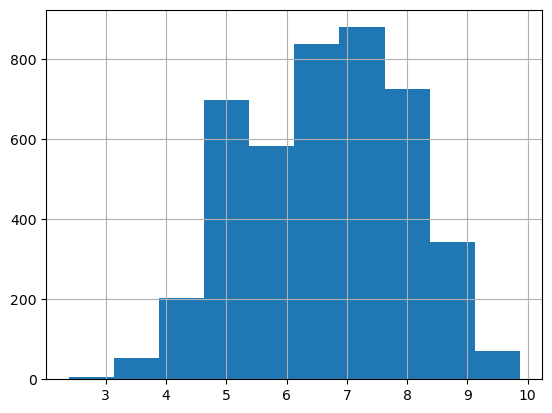

In [111]:
df_targets['y'].hist()

# Analysis of the results of the hyperparameter search

The concatenation of multiple fingerprints has given some improvement on the results, but not a lot. It seems that by making the fingerprints longer we are just adding noise to the dataset for the model.

Still, there is a good sign: the number of estimators is not hitting the end of the allowed range, which means that there is some "signal sweet spot" being hit

In [112]:
# We will load now the optimum model from the mor+rdkit+scalar paramters run:
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from pIC50_predictor.model import pIC50Predictor, find_best_params, OptimizerCallback
best_mixed_model = joblib.load('../models/run_010_mor_rdk_scalars_optimum_trained.joblib')

In [113]:
best_mixed_model.model.get_params

<bound method LGBMModel.get_params of LGBMRegressor(feature_fraction=0.5, learning_rate=0.008195307829370857,
              max_depth=np.int64(21), n_estimators=np.int64(5000),
              num_leaves=np.int64(300), random_state=33, reg_lambda=0.01,
              verbose=-1)>

np.int32(29430)

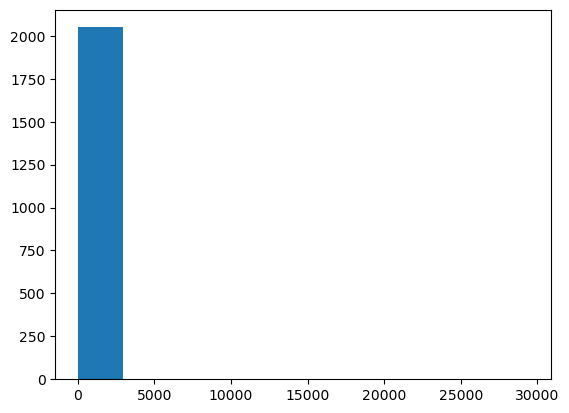

In [114]:
importances = best_mixed_model.model.feature_importances_
plt.hist(importances)
max(importances)

In [115]:
feature_importance_df = pd.DataFrame({'feature_index': range(len(importances)),'importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

print(feature_importance_df.head(10))


   feature_index  importance
0           2049       29430
1           2048       27842
2           2052       13271
3           2051        2726
4           2050        1667
5             64        1450
6            175        1262
7            843        1252
8            184        1170
9            389        1102


In [116]:
a = pd.DataFrame({'feature_index':range(len(importances)),'importance':importances})
a.sort_values(by='importance',ascending=False)

,feature_index,importance
2049,2049,29430
2048,2048,27842
2052,2052,13271
2051,2051,2726
2050,2050,1667
...,...,...
765,765,0
1127,1127,0
22,22,0
756,756,0


In [117]:
# Now, load replicas of the morgan+rdkit+scalar fingerprint runs, get their importances and average them. Indices:13, 14, 15:
importance_ratings = []
for id in range(13,17):
    opt_model = joblib.load(f'../models/run_0{id}_mor_rdk_scalars_optimum_trained.joblib')
    imps = opt_model.model.feature_importances_
    imp_df = pd.DataFrame({'feature_index': range(len(imps)),'importance': imps})
    imp_df = imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)
    importance_ratings.append(imp_df)
    print(opt_model.model.get_params())


{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.007857850902864168, 'max_depth': np.int64(50), 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': np.int64(5000), 'n_jobs': None, 'num_leaves': np.int64(384), 'objective': None, 'random_state': 33, 'reg_alpha': 0.0, 'reg_lambda': 10.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'feature_fraction': 0.17102784504928667, 'verbose': -1}
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.007092829206171447, 'max_depth': np.int64(50), 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': np.int64(3778), 'n_jobs': None, 'num_leaves': np.int64(543), 'objective': None, 'random_state': 33, 'reg_alpha': 0.0, 'reg_lambda': 10.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'feature_fractio

2053


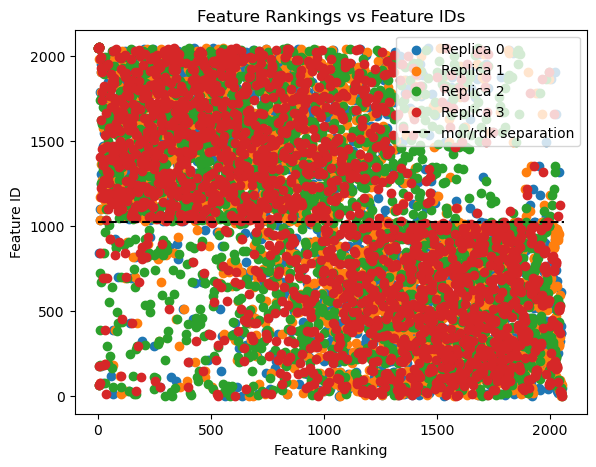

In [118]:
n_top_features = len(importance_ratings[0]['feature_index'])
print(n_top_features)
f = plt.figure()
ax = f.add_axes((0.1,0.1,0.8,0.8))
for id in range(4):
    ax.scatter(range(n_top_features), importance_ratings[id]['feature_index'][:n_top_features], label=f'Replica {id}')
    ax.set_xlabel('Feature Ranking')
    ax.set_ylabel('Feature ID')

ax.hlines(1024,0,2060, color='black', linestyle='--', label='mor/rdk separation')
ax.legend()
ax.set_title('Feature Rankings vs Feature IDs')
f.savefig('Ranking_vs_ID.png')


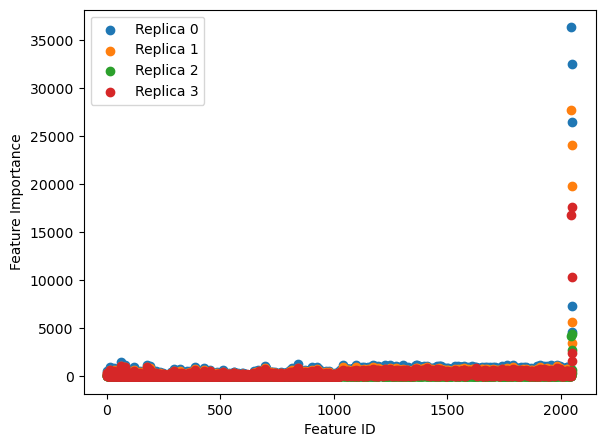

In [119]:
f = plt.figure()
ax = f.add_axes((0.1,0.1,0.8,0.8))
for id in range(4):
    ax.scatter(importance_ratings[id]['feature_index'][:n_top_features], importance_ratings[id]['importance'][:n_top_features], label=f'Replica {id}')
    ax.legend()
    ax.set_xlabel('Feature ID')
    ax.set_ylabel('Feature Importance')

#f.savefig('ID_vs_importance.png')


In [122]:
n_top_features = 100
# We calculate the union of the top 100 features from each model.
list_of_sets = []
for imp_dict in importance_ratings:
    top_n_f = set(imp_dict['feature_index'][:n_top_features])
    list_of_sets.append(top_n_f)

feature_union = set.union(*list_of_sets)

int

In [132]:
len(feature_union)
np.savetxt(f'top_feature_indices_mor_rdk_scalar.data', list(feature_union), fmt='%i')